# Seasonal Agriculture Performance Analysis

**Student Name:** Penmetesa Sai Satvika

**College Name:** Gandhi Institute of Technology and Management[GITAM]

**AICTE Student ID:** STU6a65954cd33021785042252

**Program:** VOIS AICTE Batch1 2026-2027 — Data Visualization

**Date:** 08-09-2026

---

## Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. As a result, agricultural performance may differ from one season to another. However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions.

This notebook analyzes a seasonal agriculture dataset to investigate differences in agricultural performance across seasons by identifying meaningful patterns, trends, relationships, and variations within the data.

## Objective
To explore, clean, and analyze seasonal agricultural data in order to compare performance across seasons (Kharif, Rabi, Zaid), identify significant patterns and relationships, and derive evidence-based insights and recommendations for better seasonal agricultural planning.

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(df.shape)
df.head()

(4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [2]:
print(df.dtypes)
print(df['Season'].value_counts())
print(df['Crop'].value_counts())
print(df.isna().sum()[df.isna().sum() > 0])

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

Clean And Prepare Data

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    if df[c].isna().sum() > 0:
        df[c] = df.groupby(['Season','Crop'])[c].transform(lambda x: x.fillna(x.median()))
        df[c] = df[c].fillna(df[c].median())

print("Missing after cleaning:", df.isna().sum().sum())

Missing after cleaning: 0


Crop    Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
Season                                                                  
Kharif     185     215        193    234     221   314        125    292
Rabi       163     201        177    233     213   274        129    237
Zaid        64      92         54     84      62   102         51     85

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             0.23   0.33     0.26       0.18
Rabi               0.23   0.32     0.27       0.18
Zaid               0.24   0.33     0.24       0.20
Crop    Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
Season                                                                  
Kharif    1.73    1.37       1.48   2.97    1.04  2.71      53.46   2.26
Rabi      1.46    1.19       1.22   2.62    0.87  2.33      43.96   2.06
Zaid      1.18    0.95       1.04   2.30    0.65  1.90      38.42   1.75


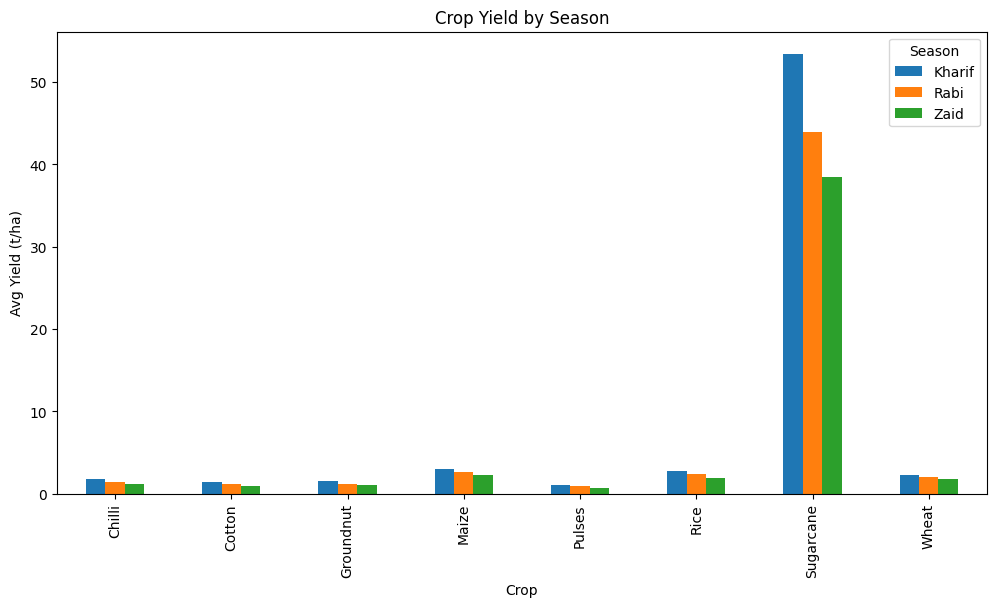

In [13]:
# Q3/Q4 — Which crops and irrigation methods dominate each season?
print(pd.crosstab(df['Season'], df['Crop']))
print()
print(pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').round(2))

# Bonus — crop performance by season
crop_season = df.groupby(['Season','Crop'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
print(crop_season)

crop_season.T.plot(kind='bar', figsize=(12,6))
plt.ylabel('Avg Yield (t/ha)')
plt.title('Crop Yield by Season')
plt.legend(title='Season')
plt.show()

How does performance/economics vary across seasons?

        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR  Revenue_INR  \
Season                                                                
Kharif             5.63              46.31   178914.65    710719.06   
Rabi               5.09              41.49    87689.47    601526.05   
Zaid               4.64              38.89   -24804.82    519171.90   

        Total_Cost_INR  
Season                  
Kharif       531804.41  
Rabi         513836.58  
Zaid         543976.73  


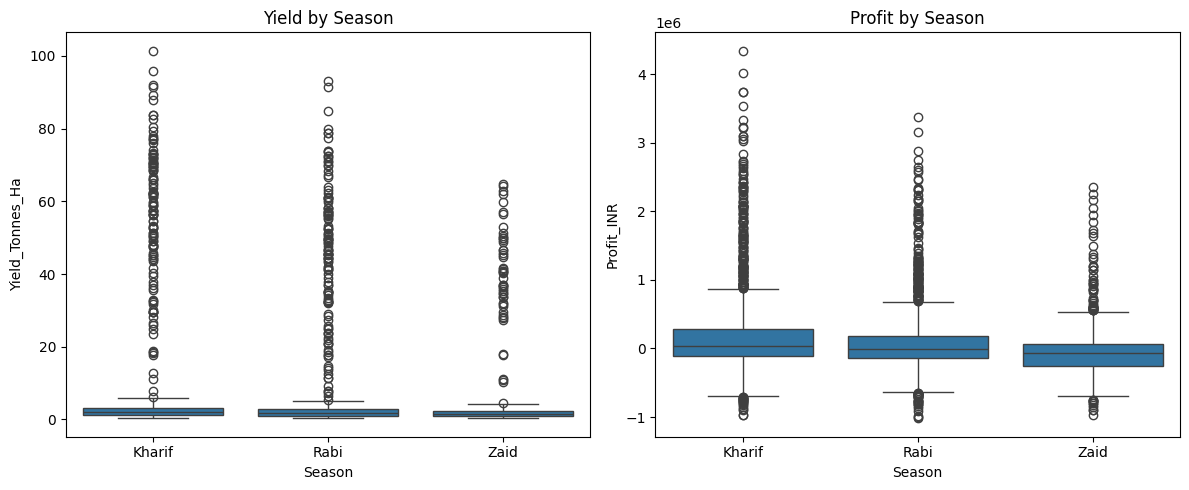

In [7]:
season_perf = df.groupby('Season')[['Yield_Tonnes_Ha','Production_Tonnes','Profit_INR','Revenue_INR','Total_Cost_INR']].mean().round(2)
print(season_perf)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0])
axes[0].set_title('Yield by Season')
sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[1])
axes[1].set_title('Profit by Season')
plt.tight_layout()
plt.show()


Are these differences statistically significant?

In [8]:
groups_yield = [df[df['Season']==s]['Yield_Tonnes_Ha'] for s in df['Season'].unique()]
f, p = stats.f_oneway(*groups_yield)
print(f"ANOVA Yield: F={f:.3f}, p={p:.5f}")

groups_profit = [df[df['Season']==s]['Profit_INR'] for s in df['Season'].unique()]
f2, p2 = stats.f_oneway(*groups_profit)
print(f"ANOVA Profit: F={f2:.3f}, p={p2:.5f}")

ANOVA Yield: F=1.458, p=0.23285
ANOVA Profit: F=34.292, p=0.00000


Resource usage across seasons

        Fertilizer_kg_ha  Pesticide_Litre_ha  Water_Used_m3  Nitrogen_kg_ha
Season                                                                     
Kharif            187.08                5.08        6102.20          120.02
Rabi              185.41                5.02        5846.99          120.40
Zaid              184.64                5.17        6419.89          120.53


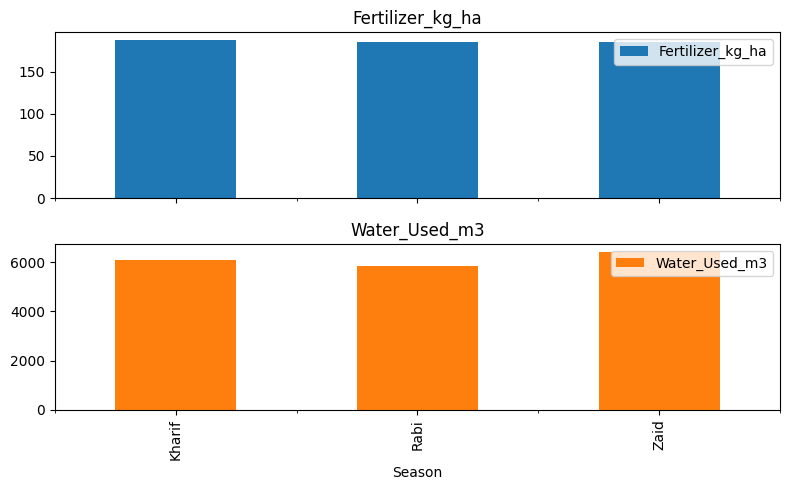

In [9]:
resource = df.groupby('Season')[['Fertilizer_kg_ha','Pesticide_Litre_ha','Water_Used_m3','Nitrogen_kg_ha']].mean().round(2)
print(resource)

resource[['Fertilizer_kg_ha','Water_Used_m3']].plot(kind='bar', figsize=(8,5), subplots=True)
plt.tight_layout()
plt.show()

Environmental conditions vs yield, per season

In [10]:
for s in df['Season'].unique():
    sub = df[df['Season']==s]
    corr = sub[['Rainfall_mm','Avg_Temperature_C','Soil_Moisture_pct','Yield_Tonnes_Ha']].corr()['Yield_Tonnes_Ha']
    print(f"\n--- {s} ---\n{corr.round(3)}")


--- Kharif ---
Rainfall_mm         -0.019
Avg_Temperature_C   -0.011
Soil_Moisture_pct    0.001
Yield_Tonnes_Ha      1.000
Name: Yield_Tonnes_Ha, dtype: float64

--- Rabi ---
Rainfall_mm          0.037
Avg_Temperature_C    0.057
Soil_Moisture_pct   -0.020
Yield_Tonnes_Ha      1.000
Name: Yield_Tonnes_Ha, dtype: float64

--- Zaid ---
Rainfall_mm          0.047
Avg_Temperature_C   -0.044
Soil_Moisture_pct   -0.030
Yield_Tonnes_Ha      1.000
Name: Yield_Tonnes_Ha, dtype: float64


Consistency across states


Season          Kharif  Rabi  Zaid
State                             
Andhra Pradesh    5.68  3.47  4.44
Gujarat           6.34  5.67  4.07
Karnataka         6.46  4.78  6.62
Madhya Pradesh    5.99  3.76  5.46
Maharashtra       5.43  5.50  2.27
Punjab            4.10  8.61  5.91
Tamil Nadu        5.52  4.50  4.10
Telangana         5.55  4.80  4.24


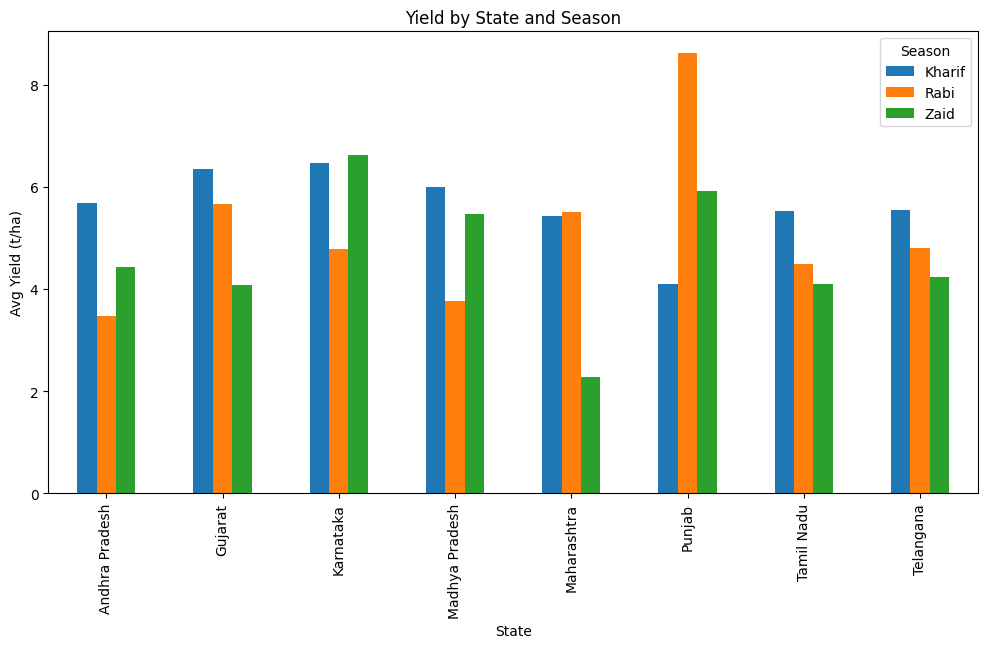

In [11]:
piv = df.groupby(['State','Season'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
print(piv)

piv.plot(kind='bar', figsize=(12,6))
plt.ylabel('Avg Yield (t/ha)')
plt.title('Yield by State and Season')
plt.show()

Full correlation heatmap + water efficiency & disease risk

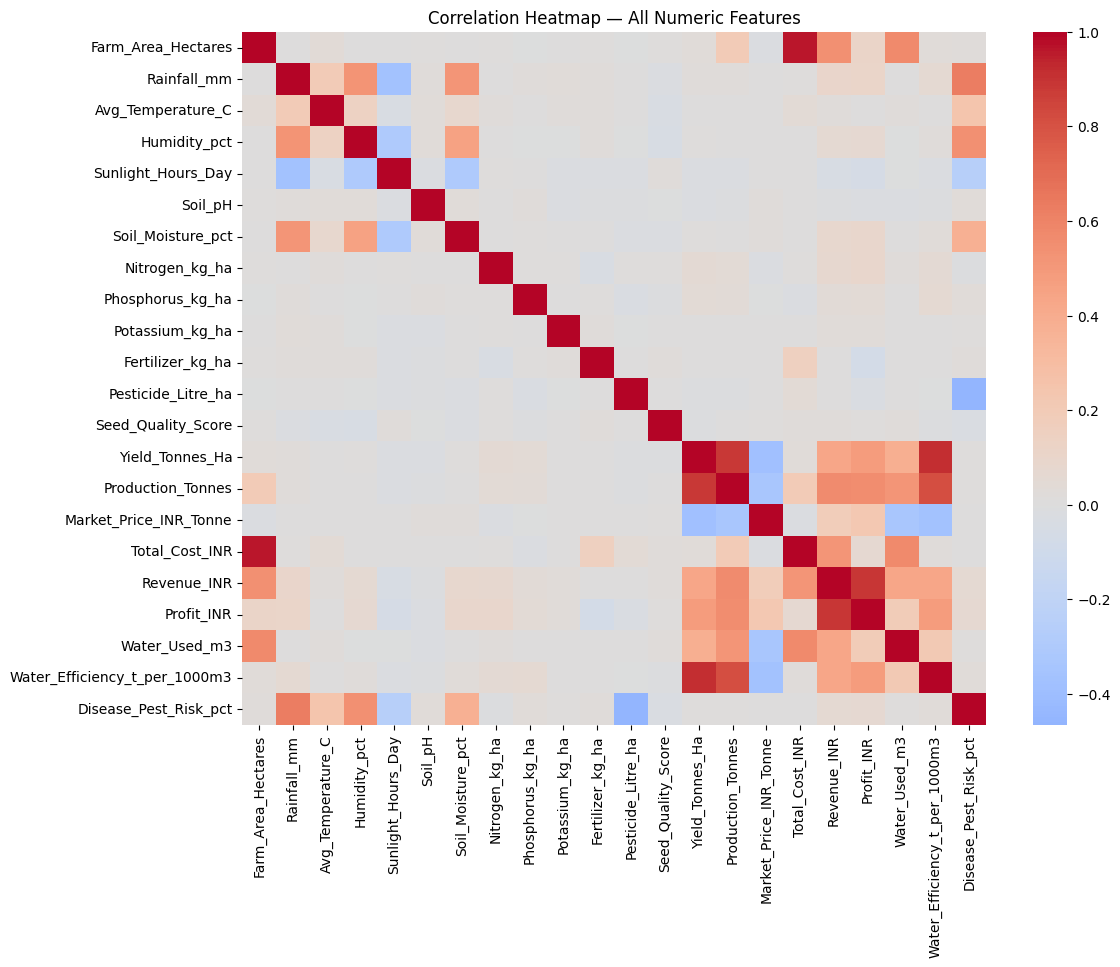

        Water_Efficiency_t_per_1000m3  Disease_Pest_Risk_pct
Season                                                      
Kharif                           5.89                  54.47
Rabi                             5.19                  40.48
Zaid                             4.41                  38.22


In [12]:
plt.figure(figsize=(12,9))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap — All Numeric Features')
plt.show()

wr = df.groupby('Season')[['Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']].mean().round(2)
print(wr)

Insights & recommendations (write this in a Markdown cell, not code)

### Key Insights
1. Profit varies significantly by season (p<0.00001) even though yield differences are not statistically significant — cost and pricing dynamics matter more than raw yield.
2. Zaid season combines the lowest yield, highest average cost, and highest water use per unit output — the least efficient season overall.
3. Environmental factors (rainfall, temperature, soil moisture) show negligible correlation with yield — farm practices (irrigation method, seed quality, fertilizer) likely matter more.
4. Kharif has the highest disease/pest risk (54.5%), consistent with monsoon-season humidity.
5. The "best" season is state-dependent, not universal — e.g., Punjab peaks in Rabi, Karnataka peaks in Zaid.

### Recommendations
- Prioritize cost control and pricing strategy in Zaid season rather than assuming yield is the main problem.
- Improve water-use efficiency in Zaid through drip/precision irrigation, given high water use for low output.
- Increase pest/disease monitoring and intervention specifically in Kharif season.
- Seasonal planning should be done per-region, not with a single national/state-wide "best season" assumption.